# 04 — Multi-asset extension (SPY / TLT / GLD)

Loads the outputs of `experiments/run_regime_comparison.py configs/multiasset.yaml` and `run_robustness.py`. Each asset is gated by its **own** independently fitted regime model; baselines are equal-weight; flat weight earns the lagged T-bill rate. OOS window: 2009-12 → 2026-06.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from regimelab import plotting

FIG = ROOT / "reports" / "figures"
OUT = ROOT / "experiments" / "outputs" / "multiasset"
net = pd.read_csv(OUT / "net_returns.csv", index_col=0, parse_dates=True)
summary = pd.read_csv(OUT / "summary.csv", index_col=0)
boot = pd.read_csv(OUT / "bootstrap_sharpe_diffs.csv", index_col=0)
at5 = summary.loc[summary.index.str.endswith("@5bps")].copy()
at5.index = at5.index.str.replace("@5bps", "")
at5[["ann_return", "ann_volatility", "sharpe", "max_drawdown",
     "avg_annual_turnover"]].sort_values("sharpe", ascending=False).round(3)

,ann_return,ann_volatility,sharpe,max_drawdown,avg_annual_turnover
strategy,,,,,
vol20q80_bh,0.075,0.075,0.819,-0.127,4.995
buy_and_hold,0.089,0.093,0.806,-0.227,0.061
hmm2p_b10_bh,0.061,0.059,0.791,-0.102,4.851
hmm2p_b05_bh,0.062,0.065,0.739,-0.121,7.375
hmm2p_bh,0.063,0.068,0.723,-0.122,11.251
vol20q80_trend,0.057,0.061,0.715,-0.133,9.160
hmm2p_b20_bh,0.050,0.051,0.713,-0.083,2.444
hmm2_bh,0.060,0.073,0.644,-0.150,9.524
trend_200d,0.058,0.072,0.625,-0.126,8.351


PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/multiasset_wealth.png')

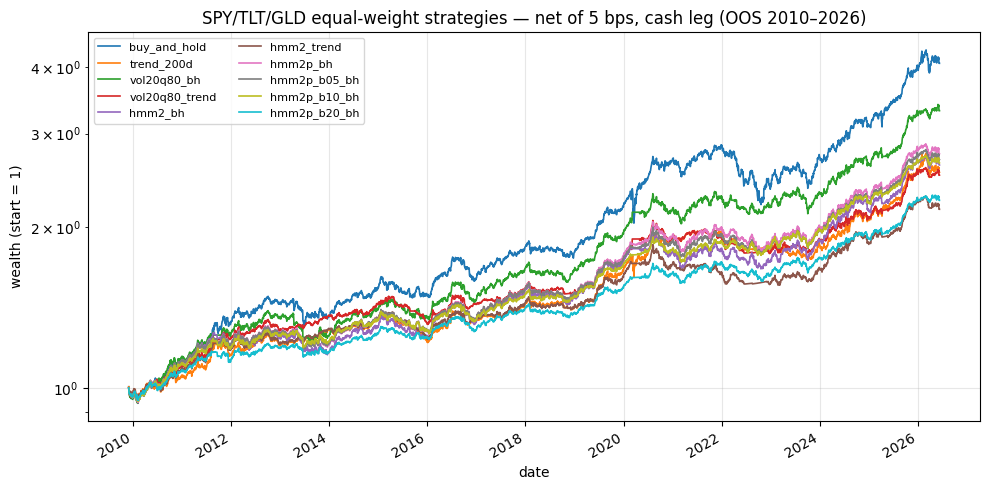

In [2]:
fig = plotting.wealth_curves(net, title="SPY/TLT/GLD equal-weight strategies — net of 5 bps, cash leg (OOS 2010–2026)")
plotting.save_figure(fig, FIG / "multiasset_wealth.png")

PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/multiasset_bootstrap.png')

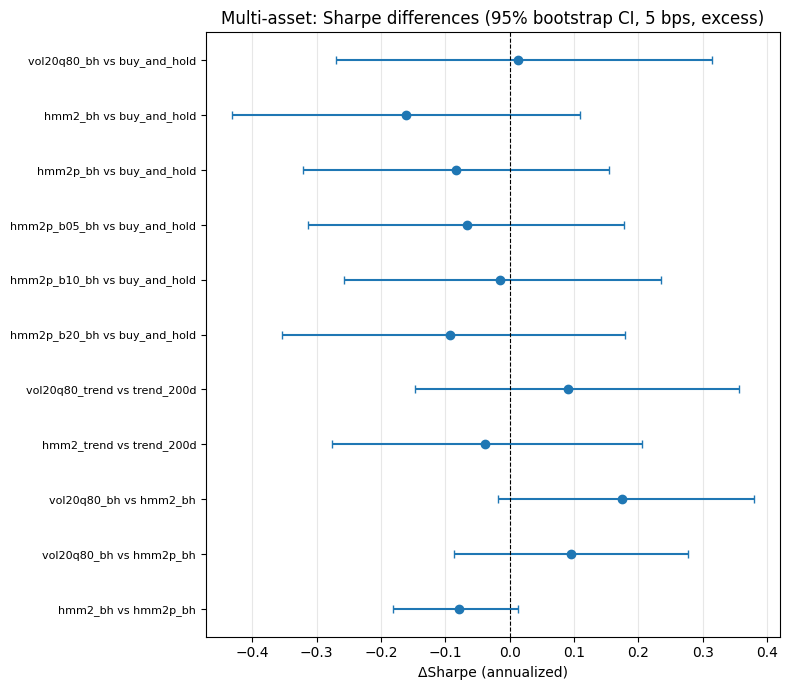

In [3]:
fig = plotting.bootstrap_forest(boot, title="Multi-asset: Sharpe differences (95% bootstrap CI, 5 bps, excess)")
plotting.save_figure(fig, FIG / "multiasset_bootstrap.png")

PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/multiasset_frontier.png')

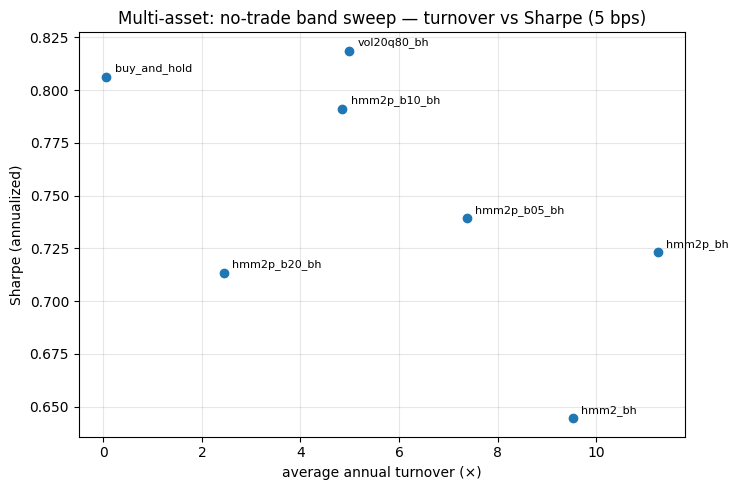

In [4]:
frontier = at5.loc[["buy_and_hold", "vol20q80_bh", "hmm2_bh", "hmm2p_bh",
                    "hmm2p_b05_bh", "hmm2p_b10_bh", "hmm2p_b20_bh"]]
fig = plotting.turnover_sharpe_frontier(frontier, title="Multi-asset: no-trade band sweep — turnover vs Sharpe (5 bps)")
plotting.save_figure(fig, FIG / "multiasset_frontier.png")

In [5]:
# Per-asset turbulent shares under each regime model.
shares = {}
for name in ["vol20q80", "hmm2"]:
    labels = pd.read_csv(OUT / f"regimes_{name}.csv", index_col=0, parse_dates=True)
    shares[name] = labels.apply(lambda s: (s > 0).mean())
pd.DataFrame(shares).round(3)

,vol20q80,hmm2
SPY,0.162,0.155
TLT,0.219,0.287
GLD,0.098,0.108


**Reading.** The diversified equal-weight portfolio earns excess Sharpe 0.81 with a −23% max drawdown unhedged, and no gated variant beats it with any confidence (vol gate +0.01, P(≤0) = 0.46; hard HMM gate −0.16, P = 0.87). The new banding result is the interesting one: the band sweep moves the HMM family from clearly-worse (hard gate, Sharpe 0.64, 9.5×/yr) to nearly matching buy-and-hold at a fraction of the risk — δ=0.10 gives Sharpe 0.79 with max drawdown −10% (vs −23%) on 4.9×/yr turnover, and δ=0.20 cuts drawdown to −8% on 2.4×/yr. Regime detection still doesn't *add* Sharpe to a diversified portfolio; banding makes its insurance much cheaper.